# Example1) PCA 2D to 1D

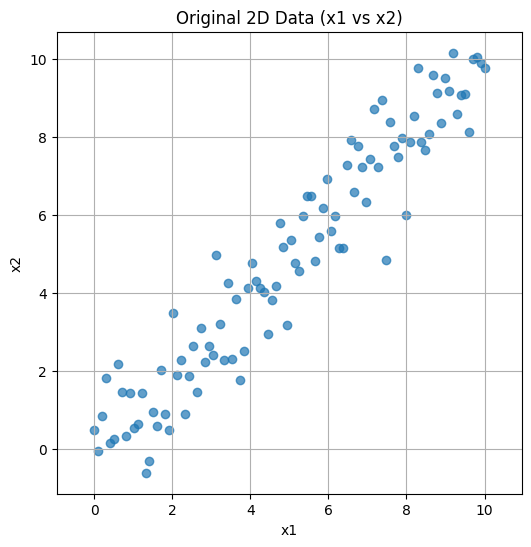

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Step 0: Create 2D dataset
# --------------------------
np.random.seed(42)
n_samples = 100

# Create data along x1 ≈ x2 with some noise
x = np.linspace(0, 10, n_samples)
y = x + np.random.normal(0, 1, n_samples)
X = np.column_stack((x, y))  # shape (100, 2)

# Plot original data
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.7)
plt.title("Original 2D Data (x1 vs x2)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis('equal')
plt.grid(True)
plt.show()


In [22]:
# Step 1: Standardize the data
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_scaled = (X - X_mean) / X_std

print("Standardized Data:\n", X_scaled[])

Standardized Data:
 [[-1.71481604 -1.42342112]
 [-1.68017329 -1.59618446]
 [-1.64553055 -1.30921113]
 [-1.6108878  -0.9933165 ]
 [-1.57624505 -1.52916474]
 [-1.5416023  -1.49647801]
 [-1.50695955 -0.87709448]
 [-1.4723168  -1.10706064]
 [-1.43767406 -1.47457625]
 [-1.40303131 -1.11445512]
 [-1.36838856 -1.4072538 ]
 [-1.33374581 -1.37532044]
 [-1.29910306 -1.11366808]
 [-1.26446031 -1.77830682]
 [-1.22981757 -1.68468149]
 [-1.19517482 -1.27583566]
 [-1.16053207 -1.38892583]
 [-1.12588932 -0.92687345]
 [-1.09124657 -1.28965309]
 [-1.05660382 -1.42012935]
 [-1.02196108 -0.45629784]
 [-0.98731833 -0.97087028]
 [-0.95267558 -0.84329136]
 [-0.91803283 -1.29343004]
 [-0.88339008 -0.97590988]
 [-0.84874733 -0.73120703]
 [-0.81410459 -1.10681357]
 [-0.77946184 -0.58017715]
 [-0.74481909 -0.8633856 ]
 [-0.71017634 -0.73074628]
 [-0.67553359 -0.79836829]
 [-0.64089084  0.02829016]
 [-0.6062481  -0.54269264]
 [-0.57160535 -0.84786242]
 [-0.5369626  -0.2068317 ]
 [-0.50231985 -0.83528053]
 [-0.467

In [23]:
# Step 2: Compute Covariance Matrix
cov_matrix = np.cov(X_scaled.T)
print("\nCovariance Matrix:\n", cov_matrix)


Covariance Matrix:
 [[1.01010101 0.96605699]
 [0.96605699 1.01010101]]


In [24]:
# Step 3: Compute Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("\nEigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)


Eigenvalues:
 [1.976158   0.04404402]

Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [25]:
# Step 4: Sort Eigenvalues and Select Top k=1
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

print("\nSorted Eigenvalues:\n", eigenvalues_sorted)
print("\nSorted Eigenvectors:\n", eigenvectors_sorted)


Sorted Eigenvalues:
 [1.976158   0.04404402]

Sorted Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [27]:
# Step 5: Project Data to 1D
k=1
W = eigenvectors_sorted[:, :k]  # Top-1 component
print(f"\nProjection Matrix W (top {k} eigenvectors):\n", W)
X_pca = X_scaled @ W  # shape (100, 1)


Projection Matrix W (top 1 eigenvectors):
 [[0.70710678]
 [0.70710678]]


In [32]:
## Step 6: Reconstruct to Original 2D Space
X_reconstructed = X_pca @ W.T  # shape (100, 2)
X_reconstructed = X_reconstructed * X_std + X_mean  # unscale

top_n=10
print("\nReconstructed Data (Approximate Original):\n", X_reconstructed[:top_n])
print("Actual data:\n",X[:top_n])



Reconstructed Data (Approximate Original):
 [[ 0.4248195   0.04639968]
 [ 0.22345593 -0.16704845]
 [ 0.69233434  0.32996906]
 [ 1.20337658  0.87168081]
 [ 0.47267795  0.09713029]
 [ 0.57083641  0.2011796 ]
 [ 1.52432976  1.21189558]
 [ 1.23957122  0.91004763]
 [ 0.75428175  0.39563416]
 [ 1.32980104  1.00569247]]
Actual data:
 [[ 0.          0.49671415]
 [ 0.1010101  -0.0372542 ]
 [ 0.2020202   0.84970874]
 [ 0.3030303   1.82606016]
 [ 0.4040404   0.16988703]
 [ 0.50505051  0.27091355]
 [ 0.60606061  2.18527342]
 [ 0.70707071  1.47450544]
 [ 0.80808081  0.33860642]
 [ 0.90909091  1.45165095]]


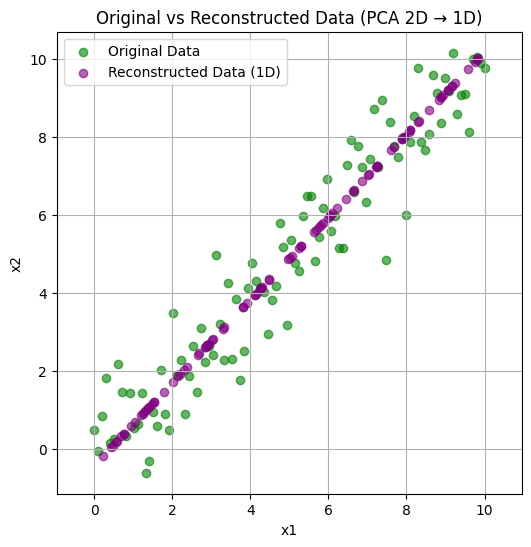


Original Data (first 5 rows):
 [[ 0.          0.49671415]
 [ 0.1010101  -0.0372542 ]
 [ 0.2020202   0.84970874]
 [ 0.3030303   1.82606016]
 [ 0.4040404   0.16988703]]

Reconstructed Data (first 5 rows):
 [[ 0.4248195   0.04639968]
 [ 0.22345593 -0.16704845]
 [ 0.69233434  0.32996906]
 [ 1.20337658  0.87168081]
 [ 0.47267795  0.09713029]]


In [33]:
# lets plot the original with reconstructed
# Assuming X (original data) and X_reconstructed are already defined

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], color='green', alpha=0.6, label='Original Data')
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], color='purple', alpha=0.6, label='Reconstructed Data (1D)')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Original vs Reconstructed Data (PCA 2D → 1D)")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

# Optional: Print a few samples to compare
print("\nOriginal Data (first 5 rows):\n", X[:5])
print("\nReconstructed Data (first 5 rows):\n", X_reconstructed[:5])

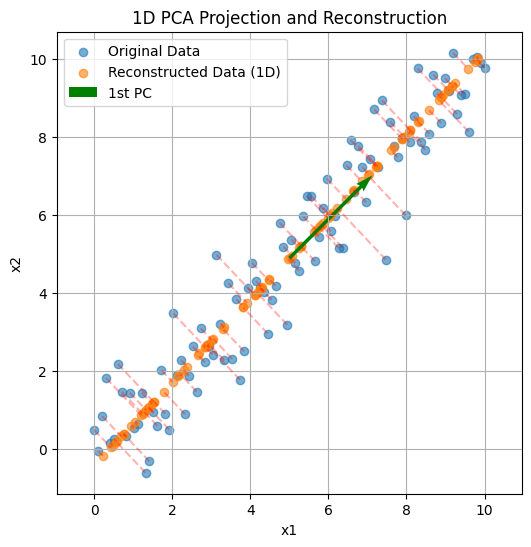

Explained Variance by 1st PC: 97.82%


In [34]:
# --------------------------
# Step 7: Plot Reconstructed vs Original
# --------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 1], alpha=0.6, label='Original Data')
ax.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.6, label='Reconstructed Data (1D)')
for i in range(n_samples):
    ax.plot([X[i, 0], X_reconstructed[i, 0]],
            [X[i, 1], X_reconstructed[i, 1]],
            'r--', alpha=0.3)

# Draw first principal component vector
origin = X_mean
pc1_vector = eigenvectors_sorted[:, 0] * 3  # scaled for visualization
ax.quiver(*origin, *pc1_vector, angles='xy', scale_units='xy', scale=1, color='green', label='1st PC')

ax.set_title("1D PCA Projection and Reconstruction")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.axis('equal')
ax.grid(True)
ax.legend()
plt.show()

# --------------------------
# Explained Variance
# --------------------------
explained_variance_ratio = eigenvalues_sorted[0] / np.sum(eigenvalues_sorted)
print(f"Explained Variance by 1st PC: {explained_variance_ratio:.2%}")


# Example 2) PCA: 3D to 2D

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# Step 0: Create a sample 3D dataset (10 samples, 3 features)
np.random.seed(42)
X = np.random.rand(10, 3) * 10  # shape: (10, 3)
print("Actual data:\n",X)

Actual data:
 [[3.74540119 9.50714306 7.31993942]
 [5.98658484 1.5601864  1.5599452 ]
 [0.58083612 8.66176146 6.01115012]
 [7.08072578 0.20584494 9.69909852]
 [8.32442641 2.12339111 1.81824967]
 [1.8340451  3.04242243 5.24756432]
 [4.31945019 2.9122914  6.11852895]
 [1.39493861 2.92144649 3.66361843]
 [4.56069984 7.85175961 1.99673782]
 [5.14234438 5.92414569 0.46450413]]


In [6]:
# Step 1: Standardize the data
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_scaled = (X - X_mean) / X_std

print("Standardized Data:\n", X_scaled)

Standardized Data:
 [[-0.2326323   1.62952924  1.03975211]
 [ 0.71266246 -0.941863   -1.00425961]
 [-1.5673943   1.35598959  0.57531055]
 [ 1.17415329 -1.38008649  1.88402884]
 [ 1.69872596 -0.75962717 -0.91259679]
 [-1.03881117 -0.46225673  0.30434182]
 [ 0.00949222 -0.50436316  0.61341538]
 [-1.22401913 -0.50140085 -0.25774276]
 [ 0.11124739  1.09389776 -0.84925786]
 [ 0.35657559  0.47018082 -1.39299167]]


In [7]:
# Step 2: Compute covariance matrix (features as columns)
cov_matrix = np.cov(X_scaled.T)  # shape: (3, 3)
print("\nCovariance Matrix:\n", cov_matrix)


Covariance Matrix:
 [[ 1.11111111 -0.52311455 -0.19816258]
 [-0.52311455  1.11111111 -0.04348754]
 [-0.19816258 -0.04348754  1.11111111]]


In [8]:
# Step 3: Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\nEigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)


Eigenvalues:
 [0.53622717 1.65728025 1.13982592]

Eigenvectors:
 [[-0.69686199 -0.71482051 -0.05843807]
 [-0.656033    0.66823293 -0.35083536]
 [-0.28983455  0.20614653  0.93461197]]


In [9]:
# Step 4: Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

print("\nSorted Eigenvalues:\n", eigenvalues_sorted)
print("\nSorted Eigenvectors:\n", eigenvectors_sorted)


Sorted Eigenvalues:
 [1.65728025 1.13982592 0.53622717]

Sorted Eigenvectors:
 [[-0.71482051 -0.05843807 -0.69686199]
 [ 0.66823293 -0.35083536 -0.656033  ]
 [ 0.20614653  0.93461197 -0.28983455]]


In [10]:
# Step 5: Select top k eigenvectors (k=2 here)
k = 2
W = eigenvectors_sorted[:, :k]  # projection matrix (3x2)
print(f"\nProjection Matrix W (top {k} eigenvectors):\n", W)


Projection Matrix W (top 2 eigenvectors):
 [[-0.71482051 -0.05843807]
 [ 0.66823293 -0.35083536]
 [ 0.20614653  0.93461197]]


In [11]:
# Step 6: Transform data to new subspace
X_pca = X_scaled @ W  # shape: (10, 2)
print("\nTransformed Data (Reduced to 2D):\n", X_pca)


Transformed Data (Reduced to 2D):
 [[ 1.46953672  0.41366288]
 [-1.34583425 -0.64980084]
 [ 2.14512076  0.15355853]
 [-1.3731421   2.1764038 ]
 [-1.9100207  -0.68569008]
 [ 0.49640736  0.50732363]
 [-0.21736385  0.74969908]
 [ 0.48676864  0.00654899]
 [ 0.47638503 -1.18400566]
 [-0.22785763 -1.48770034]]



Reconstructed Data (Approximate Original):
 [[ 1.74912603  7.05739383  6.33308691]
 [ 6.66783581  2.39619042  1.89671953]
 [ 0.6402133   8.73462676  6.04050304]
 [ 6.32254574 -0.72456336  9.32429454]
 [ 7.62896668  1.26995066  1.47445128]
 [ 3.38536625  4.94614186  6.01445518]
 [ 4.56145326  3.20926793  6.23816243]
 [ 3.47108378  5.46920902  4.68995444]
 [ 3.65363262  6.7386429   1.54833192]
 [ 4.88922899  5.61353258  0.33937731]]
Actual data:
 [[3.74540119 9.50714306 7.31993942]
 [5.98658484 1.5601864  1.5599452 ]
 [0.58083612 8.66176146 6.01115012]
 [7.08072578 0.20584494 9.69909852]
 [8.32442641 2.12339111 1.81824967]
 [1.8340451  3.04242243 5.24756432]
 [4.31945019 2.9122914  6.11852895]
 [1.39493861 2.92144649 3.66361843]
 [4.56069984 7.85175961 1.99673782]
 [5.14234438 5.92414569 0.46450413]]


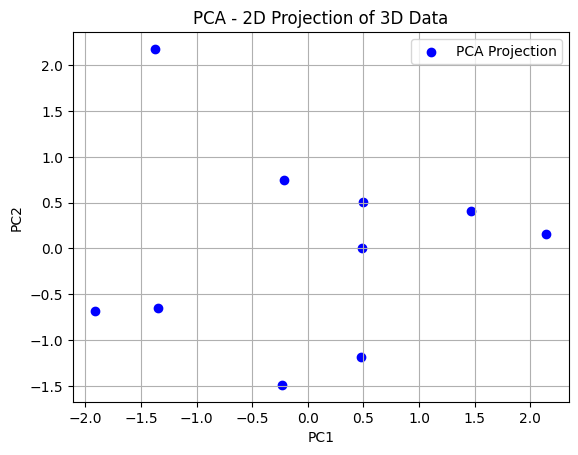

In [12]:
# Step 7 (Optional): Reconstruct original data (approximate)
X_reconstructed = X_pca @ W.T  # shape: (10, 3)
X_reconstructed = (X_reconstructed * X_std) + X_mean  # reverse standardization
print("\nReconstructed Data (Approximate Original):\n", X_reconstructed)
print("Actual data:\n",X)


# Optional: Visualize the 2D projection
plt.scatter(X_pca[:, 0], X_pca[:, 1], color='blue', label='PCA Projection')
plt.title("PCA - 2D Projection of 3D Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.legend()
plt.show()


In [13]:
# Analysis
explained_ratio = np.sum(eigenvalues_sorted[:k]) / np.sum(eigenvalues_sorted)
print(f"Explained Variance Ratio: {explained_ratio:.4f}")

Explained Variance Ratio: 0.8391
